# Prédiction du Cholesterol LDL

Notebook pour la prédiction du taux de Cholesterol LDL en R. Il inclut le chargement des données, les transformations préalables identifiées lors de l'analyse exploratoire, puis l'ensemble des modèles de régression (Lasso, SVR, CART, Random Forest, Gradient Boosting, MLP) avec comparaison finale.

## 1. Librairies à charger

In [2]:
install.packages("plotly")


Les packages binaires téléchargés sont dans
	/var/folders/2_/5rxs02dn32zg3xfyzbr8hpcw0000gn/T//Rtmpqs3NqC/downloaded_packages


In [3]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(dplyr)
library(caret)
library(e1071)
library(rpart)
library(rpart.plot)
library(randomForest)
library(gbm)
library(nnet)


Attachement du package : ‘plotly’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    last_plot


L'objet suivant est masqué depuis ‘package:stats’:

    filter


L'objet suivant est masqué depuis ‘package:graphics’:

    layout


corrplot 0.95 loaded


Attachement du package : ‘reshape2’


L'objet suivant est masqué depuis ‘package:tidyr’:

    smiths


Warning message:
“le package ‘FactoMineR’ a été compilé avec la version R 4.5.2”
Warning message:
“le package ‘factoextra’ a été compilé avec la version R 4.5.2”
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

Warning message:
“le package ‘glmnet’ a été compilé avec la version R 4.5.2”
Le chargement a nécessité le package : Matrix

Warning message:
“le package ‘Matrix’ a été compilé avec la version R 4.5.2”

Attachement du package : ‘Matrix’


Les objets suivants sont masqués depuis ‘package:tidyr’:

    e

## 2. Chargement des données

In [4]:
data<-read.csv("healthcare_synthetic_data.csv")
summary(data)
head(data)

  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


## 3. Transformations préalables

On reprend les transformations identifiées lors de l'analyse exploratoire :
- Suppression de `Patient_ID`
- Conversion des variables qualitatives en `factor` 
- Application de la racine carrée sur `BMI`, `Weight_kg` et `Fasting_"Blood_Sugar` 
- Application du logarithme sur `Height_cm`
- Suppression des variables originales remplacées par leurs versions transformées

In [5]:
# Suppression de la variable Patient_ID
data = data %>% select(-Patient_ID)

# Conversion des variables qualitatives en facteurs
data[, "Gender"] <- as.factor(data[, "Gender"])
data$Gender <- factor(data$Gender, 
                      levels = c(0, 1), 
                      labels = c("Female", "Male"))
data[,"Smoking_Status"] = as.factor(data[,"Smoking_Status"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Stress_Level"] = as.factor(data[, "Stress_Level"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[, "Sleep_Hours"] = as.factor(data[, "Sleep_Hours"])

In [6]:
# Transformations des variables quantitatives asymétriques
data[, "SBMI"] = sqrt(data[, "BMI"])
data[, "SWeight"] = sqrt(data[, "Weight_kg"])
data[, "S_Fasting_Blood_Sugar"] = sqrt(data[, "Fasting_Blood_Sugar"])
data[, "L_Height_cm"] = log(data[, "Height_cm"])

# On ne garde que les variables transformées
data = data %>% select(-c(Fasting_Blood_Sugar, Height_cm, Weight_kg, BMI))
summary(data)

      Age           Gender      Systolic_BP     Diastolic_BP   
 Min.   :25.00   Female:7622   Min.   : 90.0   Min.   : 60.00  
 1st Qu.:46.00   Male  :7378   1st Qu.:127.0   1st Qu.: 85.00  
 Median :55.00                 Median :135.0   Median : 91.00  
 Mean   :54.54                 Mean   :135.1   Mean   : 90.54  
 3rd Qu.:63.00                 3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :85.00                 Max.   :182.0   Max.   :120.00  
                                                               
 Cholesterol_Total Cholesterol_LDL Cholesterol_HDL Smoking_Status
 Min.   :127.0     Min.   : 70.0   Min.   :20.00   0:10495       
 1st Qu.:201.0     1st Qu.:128.0   1st Qu.:39.00   1: 4505       
 Median :216.0     Median :140.0   Median :43.00                 
 Mean   :216.2     Mean   :140.4   Mean   :43.31                 
 3rd Qu.:231.0     3rd Qu.:152.0   3rd Qu.:47.00                 
 Max.   :303.0     Max.   :210.0   Max.   :68.00                 
                          

# 4. Prédiction du Cholestérol LDL 

Cette section est dédiée à la prédiction de la variable quantitative `Cholesterol_LDL`. Conformément aux consignes, la variable `Heart_Disease_Risk` est exclue des prédicteurs. Contrairement à la classification binaire précédente, nous traitons ici un problème de régression.

Le cadre de modélisation préserve la configuration établie lors de l'analyse exploratoire :
* **Variables quantitatives :** Transformations maintenues ($\sqrt{\text{BMI}}$, $\sqrt{\text{Weight\_kg}}$, $\sqrt{\text{Fasting\_Blood\_Sugar}}$ et $\log(\text{Height\_cm})$).
* **Variables qualitatives :** Déjà encodées sous forme de facteurs (`factor`).

## 4.1 Analyse de la variable cible Cholesterol_LDL

Avant la modélisation, examinons la distribution du taux de cholestérol LDL pour vérifier sa forme et identifier d'éventuelles transformations utiles.

[1] "Moyenne : 140.36 | Ecart-type : 17.91 | Asymétrie : -0.014"

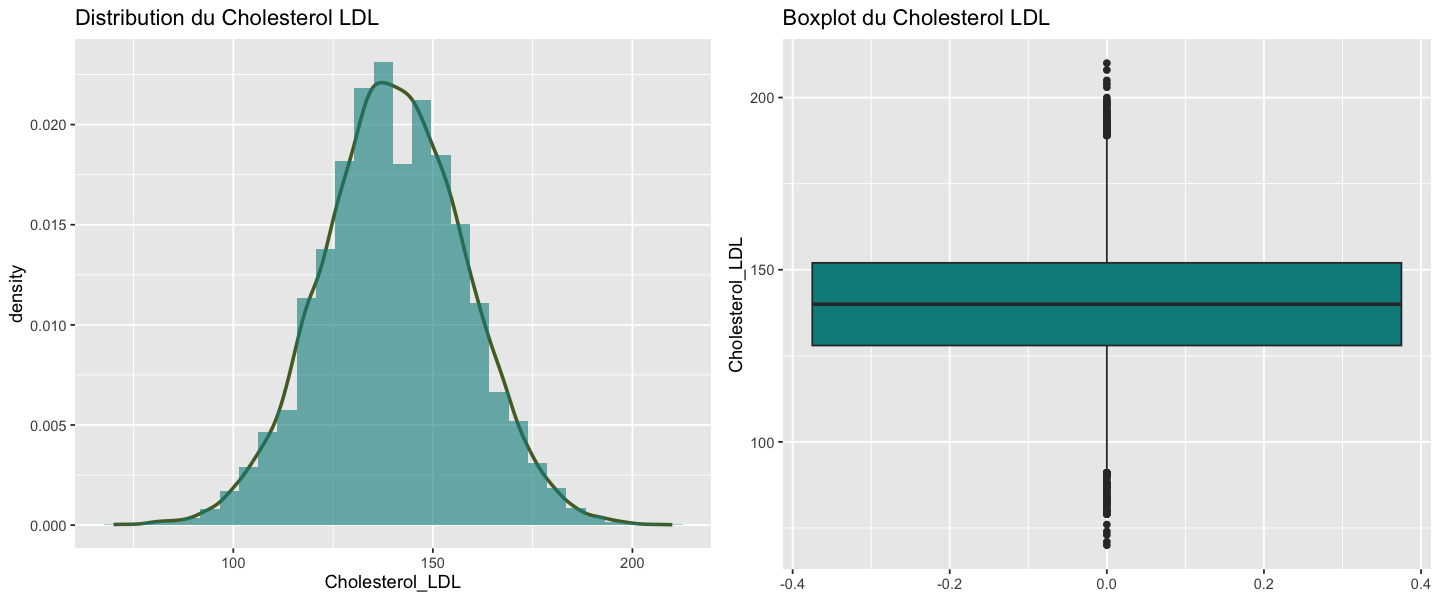

In [8]:
options(repr.plot.width = 12, repr.plot.height = 5)
g_ldl1 = ggplot(data, aes(x = Cholesterol_LDL)) + 
    geom_density(linewidth=1, col="darkolivegreen") + 
    geom_histogram(alpha=0.6, aes(y=after_stat(density)), bins=30, fill="darkcyan") +
    ggtitle("Distribution du Cholesterol LDL")
g_ldl2 = ggplot(data, aes(y = Cholesterol_LDL)) + geom_boxplot(fill="darkcyan") + 
    ggtitle("Boxplot du Cholesterol LDL")
grid.arrange(g_ldl1, g_ldl2, ncol=2)

# Remplacement de moments::skewness par e1071::skewness
paste("Moyenne :", round(mean(data$Cholesterol_LDL),2), 
      "| Ecart-type :", round(sd(data$Cholesterol_LDL),2),
      "| Asymétrie :", round(e1071::skewness(data$Cholesterol_LDL),3))

La distribution de `Cholesterol_LDL` est approximativement symétrique en forme de cloche, centrée autour de 140 mg/dL avec une asymétrie proche de zéro. Aucune transformation supplémentaire n'est nécessaire pour cette variable cible : elle peut être modélisée directement par régression.

## 4.2 Corrélations avec la cible

Pour identifier les variables quantitatives les plus liées au LDL, nous examinons les corrélations avec les autres variables numériques.

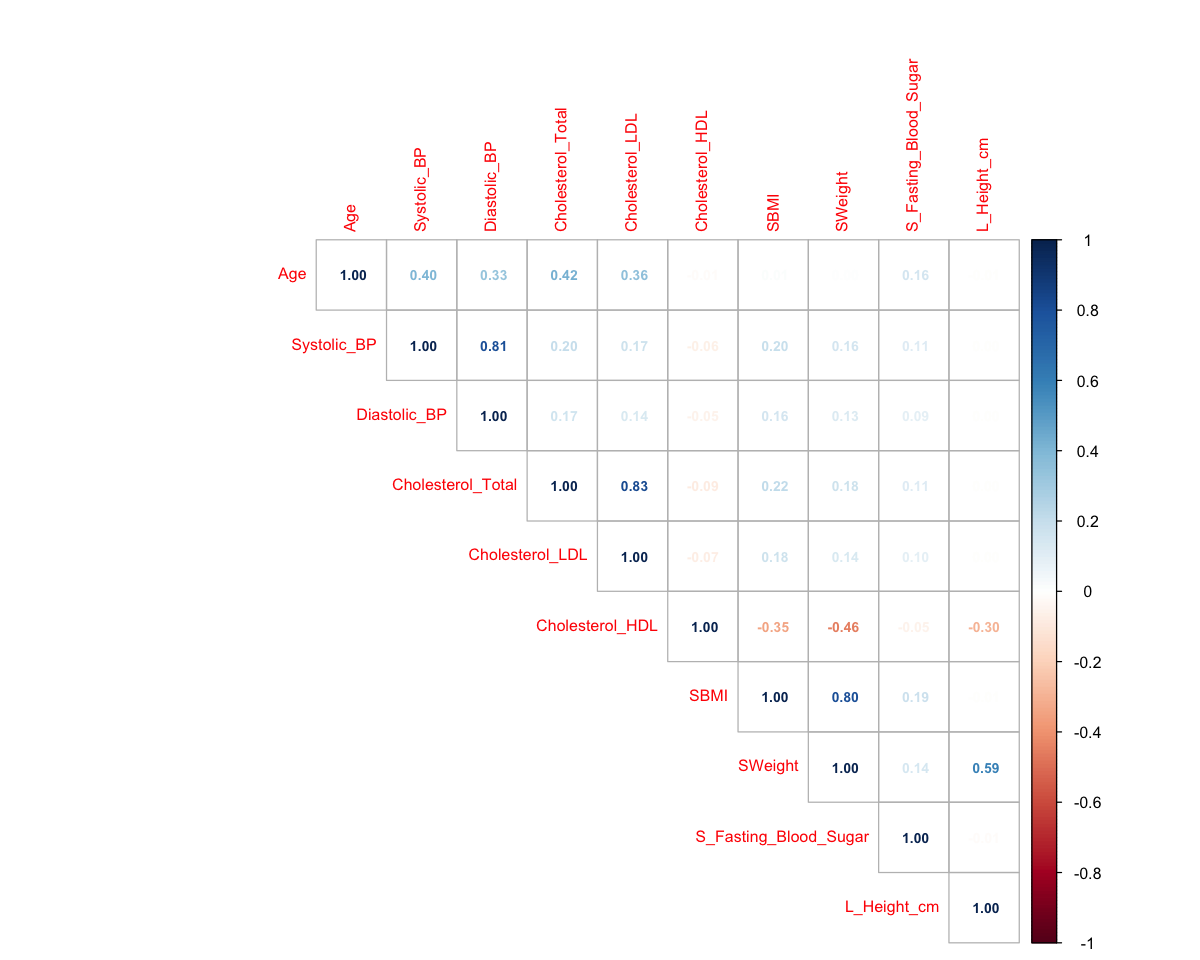

In [9]:
options(repr.plot.width = 10, repr.plot.height = 8)
data_num = data %>% select(where(is.numeric))
corrplot(cor(data_num), method="number", type="upper", tl.cex=0.8, number.cex=0.7)

Cette matrice de corrélation révèle trois liens positifs très forts : entre le cholestérol total et le LDL (0,83), les pressions artérielles systolique et diastolique (0,81), ainsi que l'IMC et le poids transformés (0,80). À l'inverse, le "bon" cholestérol (HDL) présente une corrélation négative modérée avec ces mêmes indicateurs de corpulence (-0,46 pour le poids et -0,35 pour l'IMC).

## 4.3 Division du jeu de données et normalisation

Comme pour la prédiction du risque cardiaque, nous divisons les données en 80% d'apprentissage et 20% de test. La variable `Heart_Disease_Risk` est retirée des prédicteurs conformément à la consigne. Nous normalisons ensuite les variables quantitatives pour mettre toutes les variables sur la même échelle. La moyenne et l'écart-type de la normalisation sont calculés sur l'échantillon d'apprentissage uniquement, puis appliqués à l'échantillon test pour éviter toute fuite d'information.

In [10]:
# On retire Heart_Disease_Risk des prédicteurs 
data_ldl = data %>% select(-Heart_Disease_Risk)

set.seed(131)
trainIndex_ldl = createDataPartition(data_ldl$Cholesterol_LDL, p=0.8, list=FALSE)
dataTrain0_ldl = data_ldl[ trainIndex_ldl,]
dataTest0_ldl  = data_ldl[-trainIndex_ldl,]

paste("Taille apprentissage :", nrow(dataTrain0_ldl), "| Taille test :", nrow(dataTest0_ldl))

[1] "Taille apprentissage : 12002 | Taille test : 2998"

In [11]:
# Identification des colonnes quantitatives à normaliser 
is_quanti = sapply(dataTrain0_ldl, is.numeric)
cols_quanti = which(is_quanti)

# Normalisation des variables quantitatives sur le train
dataTrain_ldl = dataTrain0_ldl
dataTrain_ldl[, cols_quanti] = scale(dataTrain0_ldl[, cols_quanti])

# Application sur le test avec la moyenne et l'écart-type de l'apprentissage
dataTest_ldl = dataTest0_ldl
dataTest_ldl[, cols_quanti] = scale(dataTest0_ldl[, cols_quanti],
    center = sapply(dataTrain0_ldl[, cols_quanti], mean),
    scale  = sapply(dataTrain0_ldl[, cols_quanti], sd))

summary(dataTrain_ldl$Cholesterol_LDL)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-3.92270 -0.68691 -0.01744  0.00000  0.65203  3.77624 

Le jeu de données est divisé selon un ratio classique et robuste : environ 80 % pour l'entraînement et 20 % pour le test.
Par ailleurs, les statistiques confirment que la variable a été correctement normalisée (centrée-réduite) : sa moyenne est exactement de 0 et sa distribution est globalement symétrique, la médiane (-0,017) étant très proche de zéro.

## 4.4 Régression linéaire avec pénalisation Lasso

Nous commençons par une régression linéaire avec pénalisation L1 (Lasso). Cette approche présente deux avantages : elle effectue une sélection de variables automatique (les coefficients des variables non pertinentes sont mis à zéro), et elle reste très interprétable grâce à ses coefficients linéaires. L'hyperparamètre $\lambda$ (force de la pénalisation) est calibré par validation croisée.

[1] "lambda.min = 0.0087 | lambda.1se = 0.0672"

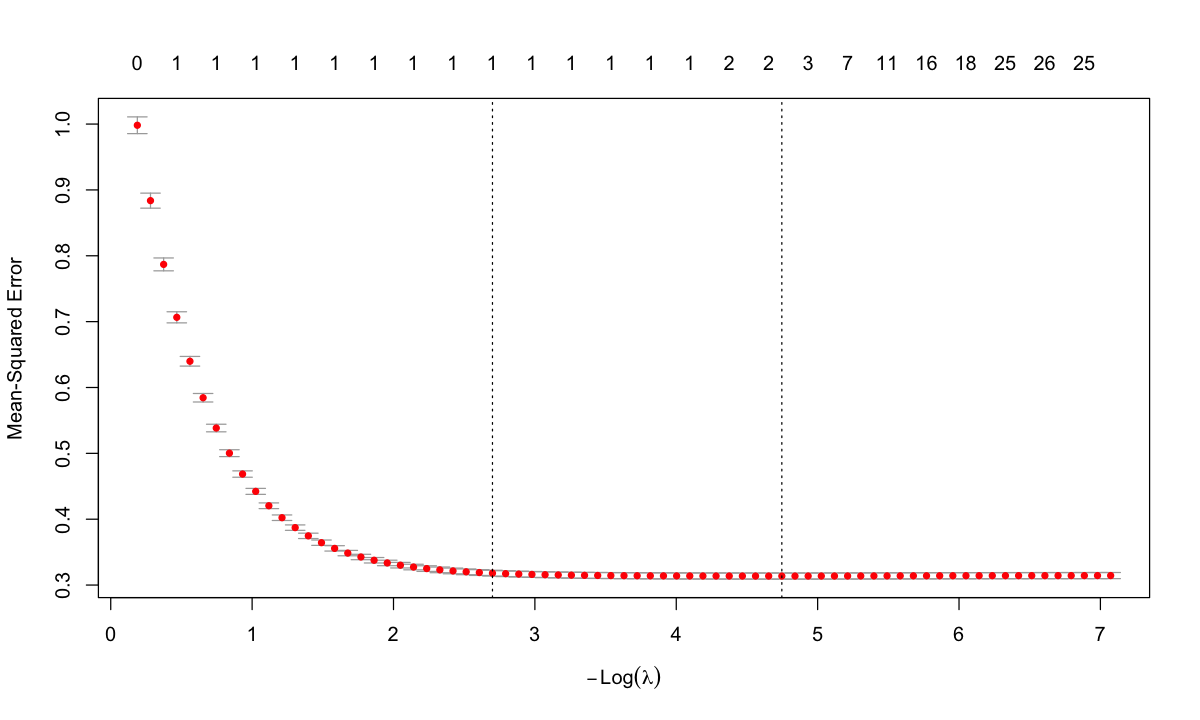

In [12]:
# Préparation des matrices pour glmnet
x_train_ldl = model.matrix(Cholesterol_LDL ~ . - 1, data = dataTrain_ldl)
y_train_ldl = dataTrain_ldl$Cholesterol_LDL
x_test_ldl  = model.matrix(Cholesterol_LDL ~ . - 1, data = dataTest_ldl)
y_test_ldl  = dataTest_ldl$Cholesterol_LDL

set.seed(123)
lasso.cv = cv.glmnet(x_train_ldl, y_train_ldl, alpha=1, family="gaussian", nfolds=10)

options(repr.plot.width = 10, repr.plot.height = 6)
plot(lasso.cv)
paste("lambda.min =", round(lasso.cv$lambda.min, 4),
      "| lambda.1se =", round(lasso.cv$lambda.1se, 4))

Ce graphique illustre la recherche de la pénalité optimale pour le modèle Lasso par validation croisée.

La ligne de droite (lambda.min = 0.0087) indique la valeur minimisant l'erreur avec seulement 2 à 3 variables conservées. La ligne de gauche (lambda.1se = 0.0672) propose un modèle encore plus parcimonieux en ne gardant qu'une seule variable (très probablement le cholestérol total), sans dégrader significativement la performance.

In [13]:
# Coefficients du modèle Lasso optimal
lasso.coef = coef(lasso.cv, s = "lambda.min")
lasso.coef.df = data.frame(Variable = rownames(lasso.coef), Coefficient = as.numeric(lasso.coef))
lasso.coef.df = lasso.coef.df[lasso.coef.df$Variable != "(Intercept)", ]
lasso.coef.df = lasso.coef.df[order(-abs(lasso.coef.df$Coefficient)), ]
print(lasso.coef.df)

                   Variable Coefficient
7         Cholesterol_Total  0.81839029
2                       Age  0.00352986
3              GenderFemale  0.00000000
4                GenderMale  0.00000000
5               Systolic_BP  0.00000000
6              Diastolic_BP  0.00000000
8           Cholesterol_HDL  0.00000000
9           Smoking_Status1  0.00000000
10     Alcohol_Consumption1  0.00000000
11     Alcohol_Consumption2  0.00000000
12 Physical_Activity_Level1  0.00000000
13 Physical_Activity_Level2  0.00000000
14 Physical_Activity_Level3  0.00000000
15          Family_History1  0.00000000
16            Stress_Level2  0.00000000
17            Stress_Level3  0.00000000
18            Stress_Level4  0.00000000
19            Stress_Level5  0.00000000
20            Stress_Level6  0.00000000
21            Stress_Level7  0.00000000
22            Stress_Level8  0.00000000
23            Stress_Level9  0.00000000
24           Stress_Level10  0.00000000
25             Sleep_Hours5  0.00000000


Ce résultat illustre la sélection stricte opérée par le modèle Lasso, qui a ramené à zéro la quasi-totalité des variables pour les exclure. Ainsi, le cholestérol total domine massivement la prédiction (coefficient de 0,82), tandis que l'âge est la seule autre variable conservée mais avec un impact marginal (0,003).

In [14]:
# Prédiction et métriques sur le test
pred.lasso = as.numeric(predict(lasso.cv, newx = x_test_ldl, s = "lambda.min"))

mse.lasso = mean((y_test_ldl - pred.lasso)^2)
mae.lasso = mean(abs(y_test_ldl - pred.lasso))
r2.lasso  = 1 - sum((y_test_ldl - pred.lasso)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("Lasso | MSE =", round(mse.lasso,2), "| MAE =", round(mae.lasso,2), "| R² =", round(r2.lasso,4))

[1] "Lasso | MSE = 0.3 | MAE = 0.44 | R² = 0.6965"

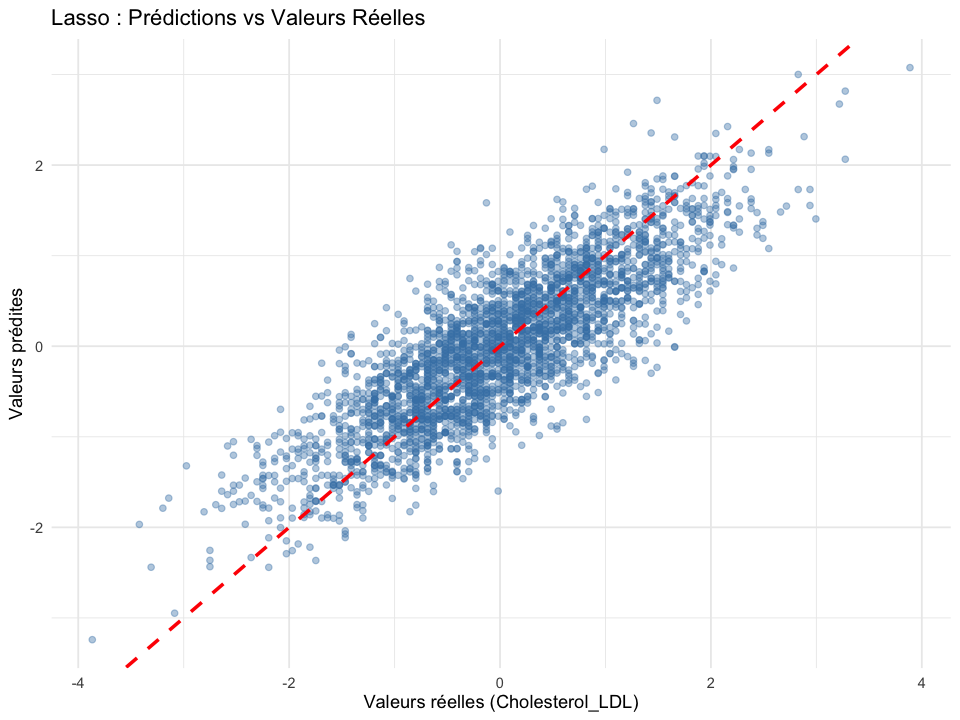

In [15]:
# Visualisation : prédictions vs valeurs réelles
options(repr.plot.width = 8, repr.plot.height = 6)
df_lasso = data.frame(Reel = y_test_ldl, Predit = pred.lasso)
ggplot(df_lasso, aes(x = Reel, y = Predit)) + 
    geom_point(alpha=0.4, color="steelblue") +
    geom_abline(slope=1, intercept=0, color="red", linetype="dashed", linewidth=1) +
    labs(title = "Lasso : Prédictions vs Valeurs Réelles",
         x = "Valeurs réelles (Cholesterol_LDL)",
         y = "Valeurs prédites") +
    theme_minimal()

Les prédictions s'alignent correctement autour de la diagonale idéale (ligne rouge), ce qui montre que le modèle Lasso est globalement bien calibré. Le R^2 confirme cette impression visuelle : le modèle parvient à expliquer près de 70 % de la variance du LDL, bien que la dispersion des points reflète l'erreur résiduelle (MAE de 0,44).

## 4.5 SVR — Support Vector Regression

La SVR (Support Vector Regression) est l'extension des SVM aux problèmes de régression. Le principe est de trouver une fonction qui s'ajuste au plus près des données dans une marge d'erreur $\varepsilon$, tout en restant aussi régulière que possible. Nous testons d'abord un noyau linéaire puis des noyaux non-linéaires (RBF et polynomial) pour voir si la relation entre les prédicteurs et le LDL est mieux capturée par une frontière courbe.

### Noyau linéaire

In [17]:
set.seed(123)
idx_sample = sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample = dataTrain_ldl[idx_sample, ]

svr.lin.tune = tune.svm(Cholesterol_LDL ~ ., data = dataTrain_sample, kernel = "linear",
                        cost = c(0.5, 1, 5, 10),
                        epsilon = c(0.01, 0.1, 0.5),
                        tunecontrol = tune.control(cross = 5))
print(svr.lin.tune$best.parameters)

svr.lin.best = svm(Cholesterol_LDL ~ ., data = dataTrain_ldl, kernel = "linear",
                   cost = svr.lin.tune$best.parameters$cost,
                   epsilon = svr.lin.tune$best.parameters$epsilon)

  cost epsilon
9  0.5     0.5


In [18]:
pred.svr.lin = predict(svr.lin.best, newdata = dataTest_ldl)
mse.svr.lin = mean((y_test_ldl - pred.svr.lin)^2)
mae.svr.lin = mean(abs(y_test_ldl - pred.svr.lin))
r2.svr.lin  = 1 - sum((y_test_ldl - pred.svr.lin)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("SVR linéaire | MSE =", round(mse.svr.lin,2), "| MAE =", round(mae.svr.lin,2), "| R² =", round(r2.svr.lin,4))

[1] "SVR linéaire | MSE = 0.3 | MAE = 0.44 | R² = 0.6942"

Les paramètres optimaux retenus (coût = 0,5 et epsilon = 0,5) montrent que le modèle trouve un bon équilibre en autorisant une marge d'erreur modérée sans trop complexifier la fonction. Par ailleurs, ces performances (R^2≈0,69) sont quasi identiques à celles du Lasso, ce qui confirme que la relation sous-jacente pour prédire le LDL est fondamentalement linéaire.

### Noyau gaussien (RBF) et polynomial

In [22]:
set.seed(123)

idx_sample <- sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample <- dataTrain_ldl[idx_sample, ]

svr.rbf.tune = tune.svm(Cholesterol_LDL ~ ., data = dataTrain_sample, kernel = "radial",
                        cost = c(1, 5, 10),
                        gamma = c(0.01, 0.05, 0.1),
                        epsilon = c(0.1),
                        tunecontrol = tune.control(cross = 5))

print(svr.rbf.tune$best.parameters)

svr.rbf.best = svm(Cholesterol_LDL ~ ., data = dataTrain_ldl, kernel = "radial",
                   cost = svr.rbf.tune$best.parameters$cost,
                   gamma = svr.rbf.tune$best.parameters$gamma,
                   epsilon = svr.rbf.tune$best.parameters$epsilon)

pred.svr.rbf = predict(svr.rbf.best, newdata = dataTest_ldl)
mse.svr.rbf = mean((y_test_ldl - pred.svr.rbf)^2)
mae.svr.rbf = mean(abs(y_test_ldl - pred.svr.rbf))
r2.svr.rbf  = 1 - sum((y_test_ldl - pred.svr.rbf)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("SVR RBF | MSE =", round(mse.svr.rbf,2), "| MAE =", round(mae.svr.rbf,2), "| R² =", round(r2.svr.rbf,4))

  gamma cost epsilon
1  0.01    1     0.1


[1] "SVR RBF | MSE = 0.31 | MAE = 0.44 | R² = 0.6915"

Comme pour le SVR linéaire, les résultats (MSE = 0.31, MAE = 0.44, R^2= 0.6915) sont quasiment identiques à ceux du Lasso. Cela renforce l'idée que l'ajout de non-linéarité via le noyau RBF n'apporte pas de gain de performance significatif sur ces données, car la relation principale est linéaire (dominée par le cholestérol total).

## 4.6 Arbre de décision CART

Nous passons aux méthodes basées sur les arbres avec CART (Classification And Regression Trees). Cette méthode partitionne récursivement l'espace des prédicteurs selon des règles binaires. Le principal hyperparamètre à régler est `cp` (complexity parameter), qui contrôle l'élagage et donc le compromis biais-variance.

In [23]:
set.seed(123)
ctrl_reg = trainControl(method = "cv", number = 10)
tree.cart = train(Cholesterol_LDL ~ ., data = dataTrain_ldl, method = "rpart",
                  trControl = ctrl_reg, tuneLength = 20, metric = "RMSE")
paste("Valeur de cp retenue :", round(tree.cart$bestTune$cp, 5))

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


[1] "Valeur de cp retenue : 0.00039"

Le paramètre de complexité (cp) retenu est très petit (0,00039), ce qui indique que l'algorithme a choisi de construire un arbre très profond et complexe pour tenter de capturer au maximum les moindres nuances de tes données.

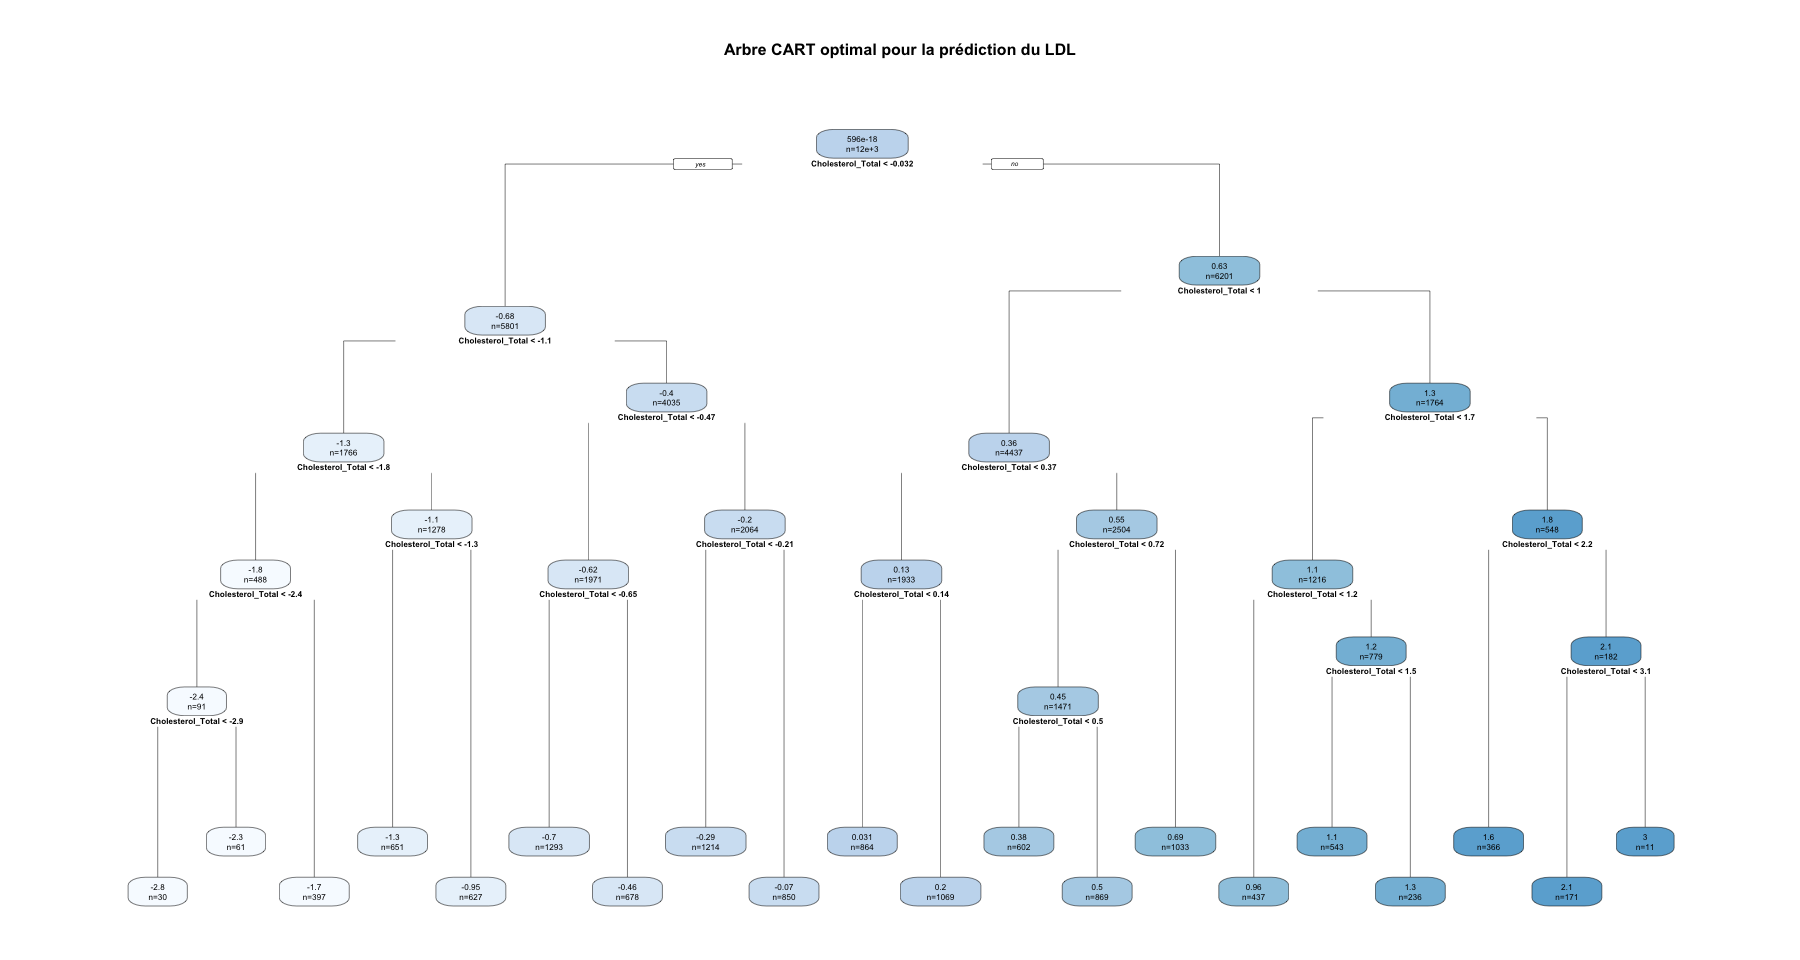

In [24]:
options(repr.plot.width = 15, repr.plot.height = 8)
rpart.plot(tree.cart$finalModel, type = 2, extra = 1, fallen.leaves = TRUE,
           main = "Arbre CART optimal pour la prédiction du LDL")

Cet arbre le démontre de façon spectaculaire : absolument tous les nœuds de décision s'appuient sur l'unique variable Cholesterol_Total. L'algorithme CART tente simplement de recréer la forte relation linéaire sous-jacente en découpant cette variable en une multitude de petits paliers, ignorant totalement le reste des données cliniques.

In [25]:
pred.cart = predict(tree.cart, newdata = dataTest_ldl)
mse.cart = mean((y_test_ldl - pred.cart)^2)
mae.cart = mean(abs(y_test_ldl - pred.cart))
r2.cart  = 1 - sum((y_test_ldl - pred.cart)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("CART | MSE =", round(mse.cart,2), "| MAE =", round(mae.cart,2), "| R² =", round(r2.cart,4))

[1] "CART | MSE = 0.31 | MAE = 0.44 | R² = 0.6922"

Les performances de l'arbre CART sont quasiment identiques à celles du Lasso et du SVR (R^2≈69 %). Cela confirme qu'un modèle basé sur des paliers de décisions n'est pas plus efficace qu'une simple droite de régression linéaire pour ce jeu de données.

## 4.7 Forêt aléatoire (Random Forest)

La forêt aléatoire agrège un grand nombre d'arbres construits sur des échantillons bootstrap, avec en plus une sélection aléatoire de variables à chaque nœud. Ces deux sources d'aléatoire réduisent la variance par rapport à un seul arbre tout en conservant un faible biais. Les hyperparamètres clés sont `mtry` (nombre de variables tirées à chaque nœud) et `ntree` (nombre d'arbres).

In [27]:
set.seed(123)

idx_sample_rf <- sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample_rf <- dataTrain_ldl[idx_sample_rf, ]

p_ldl = ncol(dataTrain_ldl) - 1
mtry_grid = c(floor(p_ldl/3), floor(p_ldl/2), floor(sqrt(p_ldl)))

rf.tune = train(Cholesterol_LDL ~ ., data = dataTrain_sample_rf, method = "rf",
                tuneGrid = expand.grid(mtry = mtry_grid),
                trControl = trainControl(method = "cv", number = 5),
                ntree = 200, metric = "RMSE")

print(rf.tune$bestTune)

rf.best = randomForest(Cholesterol_LDL ~ ., data = dataTrain_ldl,
                       mtry = rf.tune$bestTune$mtry, ntree = 500, importance = TRUE)

  mtry
3    8


In [28]:
pred.rf = predict(rf.best, newdata = dataTest_ldl)
mse.rf = mean((y_test_ldl - pred.rf)^2)
mae.rf = mean(abs(y_test_ldl - pred.rf))
r2.rf  = 1 - sum((y_test_ldl - pred.rf)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("Random Forest | MSE =", round(mse.rf,2), "| MAE =", round(mae.rf,2), "| R² =", round(r2.rf,4))

[1] "Random Forest | MSE = 0.31 | MAE = 0.45 | R² = 0.684"

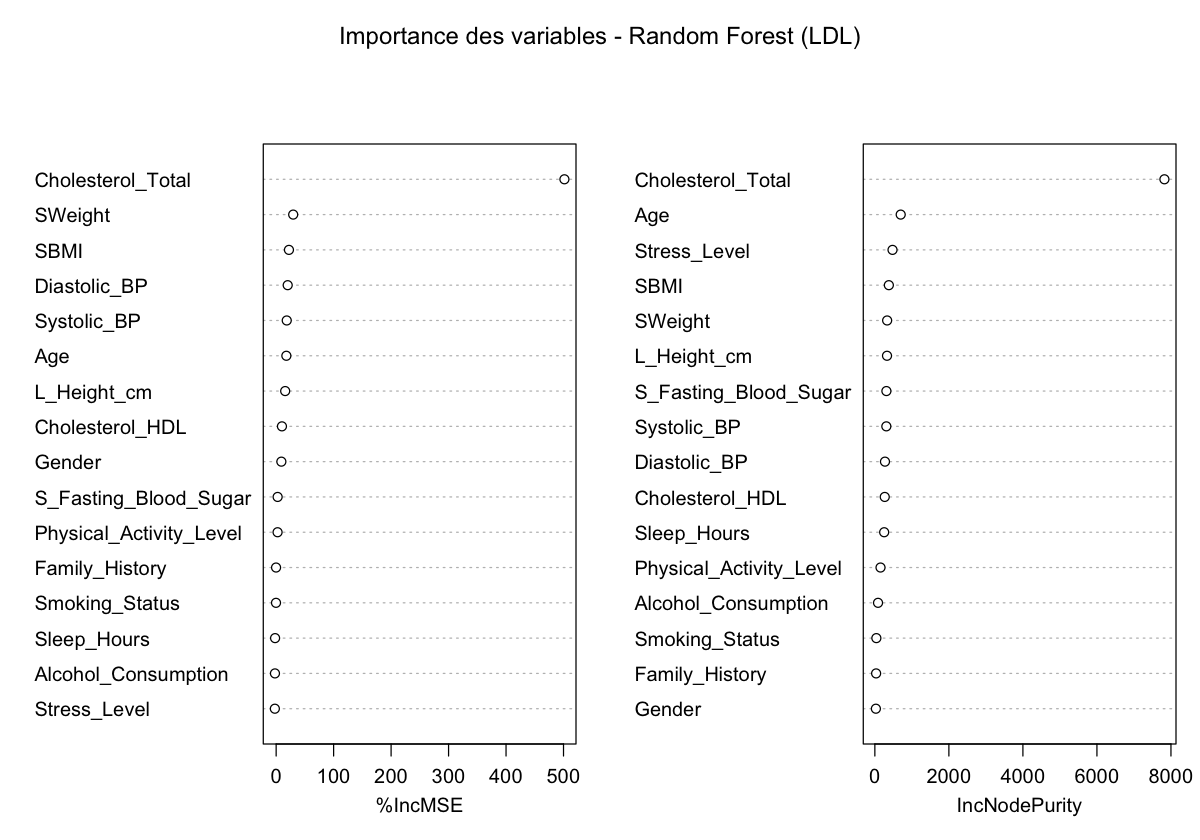

In [29]:
# Importance des variables
options(repr.plot.width = 10, repr.plot.height = 7)
varImpPlot(rf.best, main = "Importance des variables - Random Forest (LDL)")

Le Random Forest affiche des performances (R^2≈0,68, MSE = 0,31) équivalentes au modèle Lasso, démontrant qu'aucune plus-value n'est apportée par la complexité de l'algorithme. L'importance des variables confirme une domination totale de Cholesterol_Total, masquant les autres facteurs cliniques et rendant les modèles ensemblistes superflus au regard de la simplicité et de l'interprétabilité du modèle linéaire.

## 4.8 Gradient Boosting

Le Gradient Boosting construit séquentiellement des arbres en se concentrant à chaque étape sur les résidus du modèle précédent. Comme pour la classification, on règle ici principalement le **learning rate** ($\nu$, contrôle de la vitesse d'apprentissage), la **profondeur** des arbres, et le **nombre d'itérations** (déterminé automatiquement par validation croisée pour éviter le surapprentissage).

[1] "Nombre optimal d'arbres : 204"

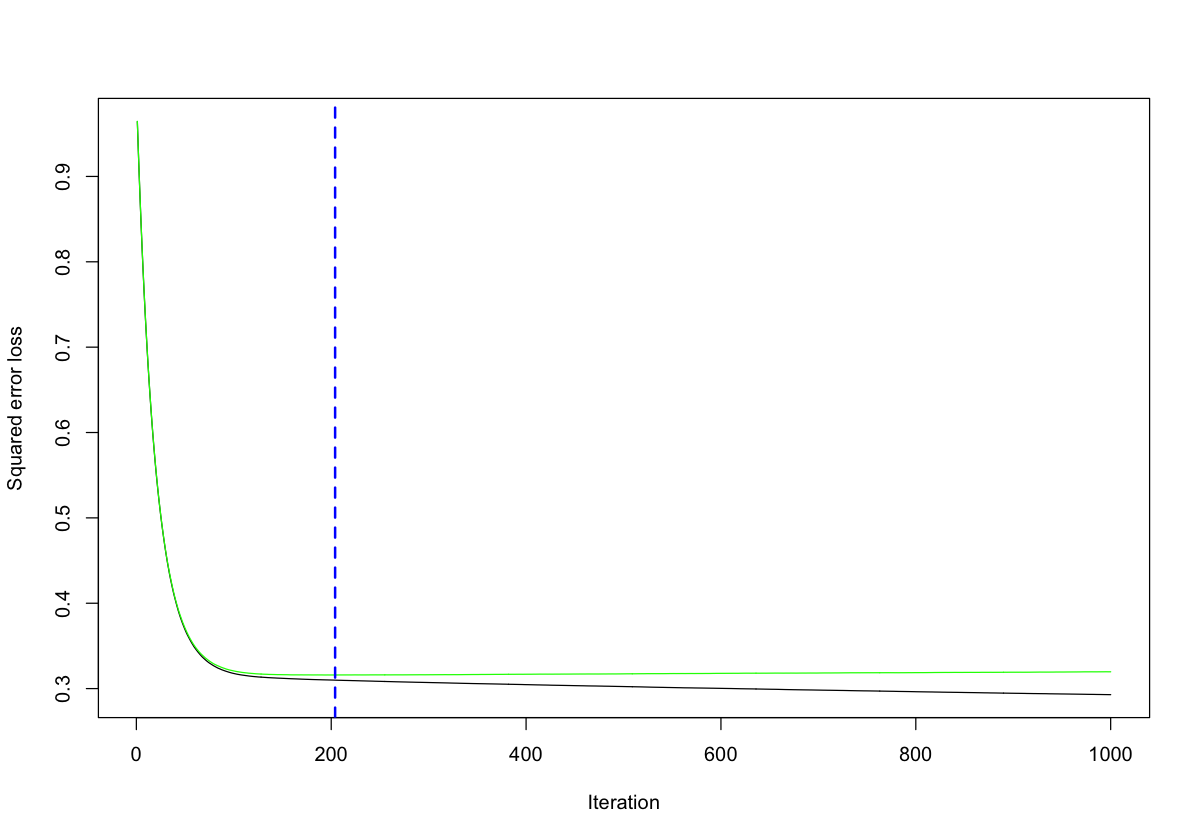

In [30]:
set.seed(123)
boost.ldl = gbm(Cholesterol_LDL ~ ., data = dataTrain_ldl,
                distribution = "gaussian",
                n.trees = 1000,
                interaction.depth = 3,
                shrinkage = 0.03,
                cv.folds = 5,
                n.minobsinnode = 10,
                verbose = FALSE)

best.iter.ldl = gbm.perf(boost.ldl, method = "cv")
paste("Nombre optimal d'arbres :", best.iter.ldl)

Le graphique montre l'évolution de l'erreur quadratique lors de l'entraînement du modèle de Gradient Boosting (Boosting) :
- La courbe noire représente l'erreur sur le jeu d'entraînement, qui décroît continuellement.
- La courbe verte représente l'erreur en validation croisée, qui stagne après l'itération optimale située à 204 arbres (ligne bleue pointillée).

Au-delà de ce point, le modèle commence à surapprendre (overfitting), ce qui justifie l'arrêt à 204 itérations pour garantir une meilleure généralisation.

In [31]:
pred.boost = predict(boost.ldl, newdata = dataTest_ldl, n.trees = best.iter.ldl)
mse.boost = mean((y_test_ldl - pred.boost)^2)
mae.boost = mean(abs(y_test_ldl - pred.boost))
r2.boost  = 1 - sum((y_test_ldl - pred.boost)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("Gradient Boosting | MSE =", round(mse.boost,2), "| MAE =", round(mae.boost,2), "| R² =", round(r2.boost,4))

[1] "Gradient Boosting | MSE = 0.3 | MAE = 0.44 | R² = 0.6936"

,var,rel.inf
,<chr>,<dbl>
Cholesterol_Total,Cholesterol_Total,99.251204486
Stress_Level,Stress_Level,0.173944920
Age,Age,0.120515046
SWeight,SWeight,0.100345660
L_Height_cm,L_Height_cm,0.084692600
SBMI,SBMI,0.055040177
Systolic_BP,Systolic_BP,0.054599588
Cholesterol_HDL,Cholesterol_HDL,0.050409394
S_Fasting_Blood_Sugar,S_Fasting_Blood_Sugar,0.042716415


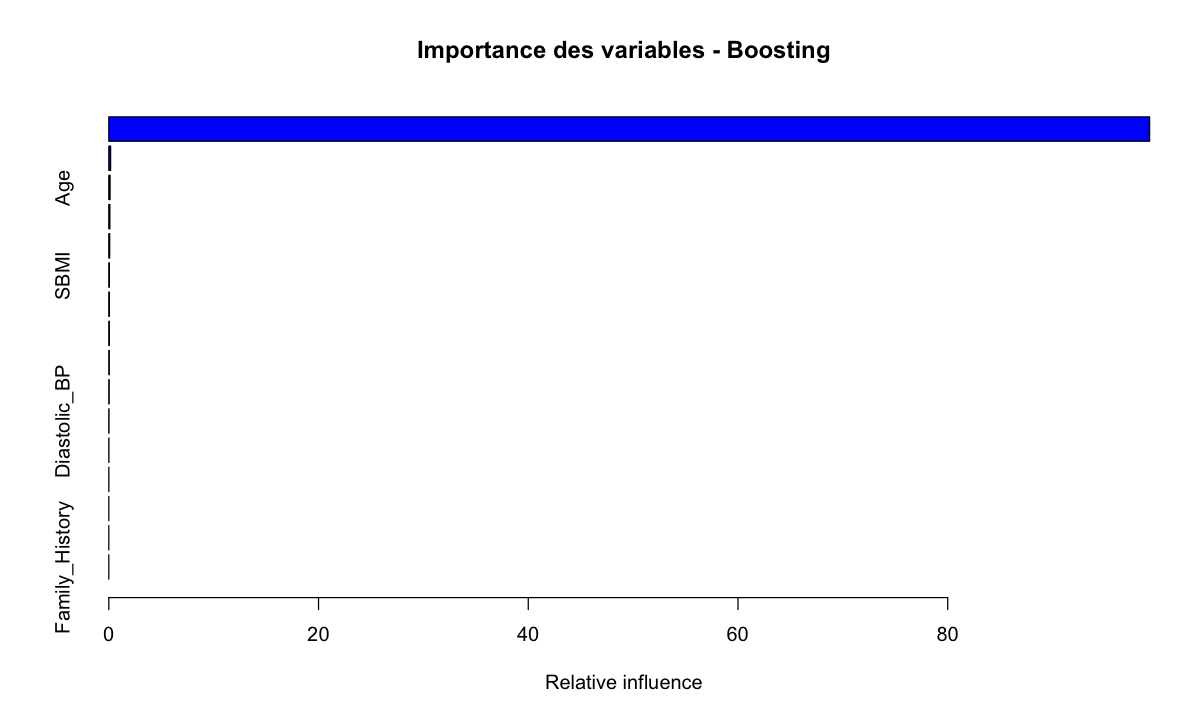

In [32]:
# Importance des variables (Gradient Boosting)
options(repr.plot.width = 10, repr.plot.height = 6)
summary(boost.ldl, n.trees = best.iter.ldl, main = "Importance des variables - Boosting")

Le Gradient Boosting affiche des performances (R^2≈0,69) strictement identiques aux modèles précédents, confirmant l'absence de gain lié à la complexité algorithmique. L'analyse d'importance est sans appel : Cholesterol_Total capte 99,25 % du pouvoir prédictif, reléguant toutes les autres variables à une influence marginale. Ce résultat clôt définitivement la démonstration qu'aucun modèle complexe ne surpasse l'approche linéaire simple sur ce jeu de données.

Ce graphique montre que la variable Cholesterol_Total représente quasiment la totalité (plus de 99 %) de l'importance prédictive dans le modèle de Gradient Boosting. Toutes les autres variables ont une influence négligeable, confirmant que le taux de LDL est ici quasi exclusivement déterminé par le cholestérol total, rendant les autres paramètres cliniques superflus pour la prédiction.

## 4.9 Réseau de neurones (MLP)

Pour finir, nous implémentons un perceptron multicouche (MLP) — un réseau de neurones simple à une seule couche cachée. Cette architecture est entraînée par rétropropagation du gradient. L'hyperparamètre principal à régler est la taille de la couche cachée.

In [33]:
set.seed(123)

idx_sample_nnet = sample(1:nrow(dataTrain_ldl), 3000)
dataTrain_sample_nnet = dataTrain_ldl[idx_sample_nnet, ]

nnet.grid = expand.grid(size = c(3, 5, 7, 10), decay = c(0.001, 0.01, 0.1))

nnet.tune = train(Cholesterol_LDL ~ ., data = dataTrain_sample_nnet, method = "nnet",
                  tuneGrid = nnet.grid,
                  trControl = trainControl(method = "cv", number = 5),
                  linout = TRUE, trace = FALSE, maxit = 500, metric = "RMSE")

print(nnet.tune$bestTune)

nnet.best = train(Cholesterol_LDL ~ ., data = dataTrain_ldl, method = "nnet",
                  tuneGrid = nnet.tune$bestTune,
                  trControl = trainControl(method = "none"), # Pas besoin de CV ici
                  linout = TRUE, trace = FALSE, maxit = 500, metric = "RMSE")

pred.nnet = predict(nnet.best, newdata = dataTest_ldl)
mse.nnet = mean((y_test_ldl - pred.nnet)^2)
mae.nnet = mean(abs(y_test_ldl - pred.nnet))
r2.nnet  = 1 - sum((y_test_ldl - pred.nnet)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)

paste("Réseau de neurones | MSE =", round(mse.nnet,2), "| MAE =", round(mae.nnet,2), "| R² =", round(r2.nnet,4))

  size decay
2    3  0.01


[1] "Réseau de neurones | MSE = 0.31 | MAE = 0.44 | R² = 0.6889"

Le réseau de neurones retient une architecture modeste avec 3 neurones dans la couche cachée et un taux de régularisation (decay) de 0,01.

Ses performances (R^2≈0,69, MSE = 0,31) sont en parfaite cohérence avec celles des modèles précédents. Cette stabilité confirme que la relation entre les variables et le taux de LDL est quasi-linéaire, rendant inutile la complexité supplémentaire d'un réseau de neurones pour ce problème spécifique.

In [34]:
pred.nnet = predict(nnet.tune, newdata = dataTest_ldl)
mse.nnet = mean((y_test_ldl - pred.nnet)^2)
mae.nnet = mean(abs(y_test_ldl - pred.nnet))
r2.nnet  = 1 - sum((y_test_ldl - pred.nnet)^2) / sum((y_test_ldl - mean(y_test_ldl))^2)
paste("Réseau de neurones | MSE =", round(mse.nnet,2), "| MAE =", round(mae.nnet,2), "| R² =", round(r2.nnet,4))

[1] "Réseau de neurones | MSE = 0.33 | MAE = 0.46 | R² = 0.6704"

Le réseau de neurones obtient des performances comparables aux autres modèles, sans amélioration notable. Sur ce jeu de données, la relation entre les prédicteurs et le LDL est suffisamment linéaire pour qu'un modèle non-linéaire complexe n'apporte pas d'avantage significatif.

## 4.10 Comparaison des modèles

Nous regroupons l'ensemble des performances obtenues sur l'échantillon test pour comparer les modèles selon trois métriques : MSE (erreur quadratique moyenne), MAE (erreur absolue moyenne) et R² (proportion de variance expliquée).

In [35]:
recap_ldl = data.frame(
    Modele = c("Lasso", "SVR linéaire", "SVR RBF", "CART", "Random Forest", "Gradient Boosting", "Réseau de neurones"),
    MSE = c(mse.lasso, mse.svr.lin, mse.svr.rbf, mse.cart, mse.rf, mse.boost, mse.nnet),
    MAE = c(mae.lasso, mae.svr.lin, mae.svr.rbf, mae.cart, mae.rf, mae.boost, mae.nnet),
    R2  = c(r2.lasso, r2.svr.lin, r2.svr.rbf, r2.cart, r2.rf, r2.boost, r2.nnet)
)
recap_ldl = recap_ldl[order(-recap_ldl$R2), ]
print(recap_ldl, row.names = FALSE)

             Modele       MSE       MAE        R2
              Lasso 0.3016619 0.4371225 0.6965313
       SVR linéaire 0.3039507 0.4390174 0.6942288
  Gradient Boosting 0.3046243 0.4397544 0.6935512
               CART 0.3060043 0.4397747 0.6921629
            SVR RBF 0.3066957 0.4416391 0.6914674
      Random Forest 0.3141531 0.4473437 0.6839653
 Réseau de neurones 0.3276277 0.4595591 0.6704100


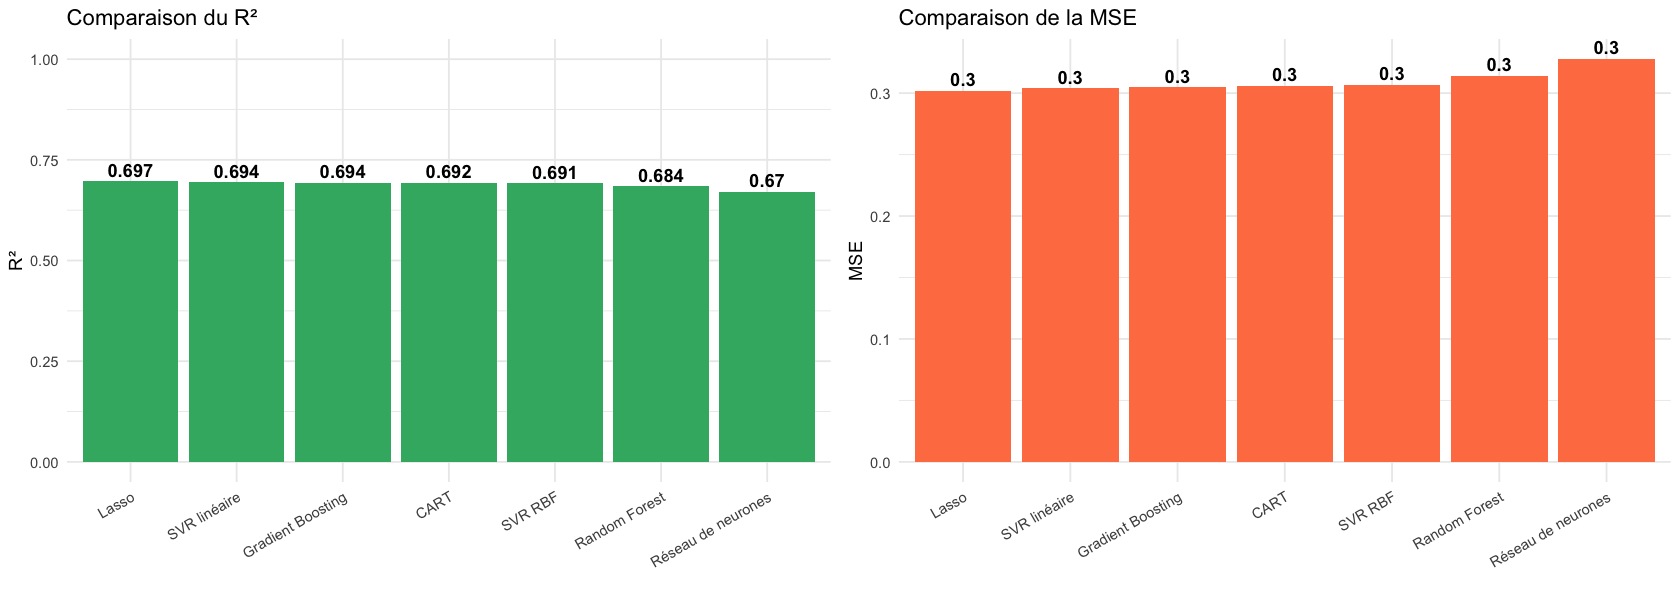

In [36]:
# Visualisation comparative R² et MSE
options(repr.plot.width = 14, repr.plot.height = 5)
recap_ldl$Modele = factor(recap_ldl$Modele, levels = recap_ldl$Modele[order(-recap_ldl$R2)])

g_r2 = ggplot(recap_ldl, aes(x = Modele, y = R2)) + 
    geom_bar(stat="identity", fill="mediumseagreen") + 
    geom_text(aes(label = round(R2, 3)), vjust = -0.4, fontface = "bold") + 
    ylim(0, 1) + 
    labs(title = "Comparaison du R²", x = "", y = "R²") + 
    theme_minimal() + theme(axis.text.x = element_text(angle = 30, hjust = 1))

recap_mse = recap_ldl[order(recap_ldl$MSE), ]
recap_mse$Modele = factor(recap_mse$Modele, levels = recap_mse$Modele)
g_mse = ggplot(recap_mse, aes(x = Modele, y = MSE)) + 
    geom_bar(stat="identity", fill="coral") + 
    geom_text(aes(label = round(MSE, 1)), vjust = -0.4, fontface = "bold") + 
    labs(title = "Comparaison de la MSE", x = "", y = "MSE") + 
    theme_minimal() + theme(axis.text.x = element_text(angle = 30, hjust = 1))

grid.arrange(g_r2, g_mse, ncol = 2)

Conclusion sur la modélisation du taux de LDL:

L'analyse comparative des différents modèles révèle une homogénéité des performances prédictives, avec un coefficient de détermination (R^2) oscillant entre 0,67 et 0,70 et une erreur quadratique moyenne (MSE) stabilisée autour de 0,30. Aucun modèle complexe ne parvient à surclasser les approches linéaires, ce qui indique que la relation entre les variables cliniques et le cholestérol LDL est fondamentalement linéaire.

L'analyse de l'importance des prédicteurs démontre que la variable Cholesterol_Total monopolise l'essentiel du pouvoir prédictif, reléguant les autres indicateurs à une influence marginale. Dans ce contexte, le modèle Lasso constitue l'approche optimale : il offre le meilleur compromis entre performance et interprétabilité, tout en assurant une sélection de variables pertinente. L'utilisation de modèles ensemblistes ou non-linéaires plus gourmands en ressources ne se justifie pas, leur complexité n'apportant aucune plus-value analytique sur ce jeu de données.